<a href="https://colab.research.google.com/github/YashwanthDeeshetti/Optimizing-global-supply-chain/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


   DATASET DICTIONARY: 20 SUPPLY CHAIN VARIABLES
          Variable Name             Category
      Base_Demand_Index          Core Driver
      Product_Price_USD          Core Driver
    Marketing_Spend_USD          Core Driver
        Customer_Rating          Core Driver
Shipping_Distance_Miles          Core Driver
 Seasonality_Multiplier          Core Driver
   Macro_Economic_Index          Core Driver
   Competitor_Price_USD          Core Driver
         Ad_Impressions Correlated/Redundant
              Ad_Clicks Correlated/Redundant
       Search_Page_Rank Correlated/Redundant
     Total_Review_Count Correlated/Redundant
        Return_Rate_Pct Correlated/Redundant
      Est_Shipping_Days Correlated/Redundant
     Product_Weight_Lbs Correlated/Redundant
        Box_Volume_CuIn Correlated/Redundant
   Fulfillment_Cost_USD Correlated/Redundant
    Warehouse_Stock_Qty Correlated/Redundant
    Discount_Percentage Correlated/Redundant
  Lightning_Deal_Active Correlated/Redundant



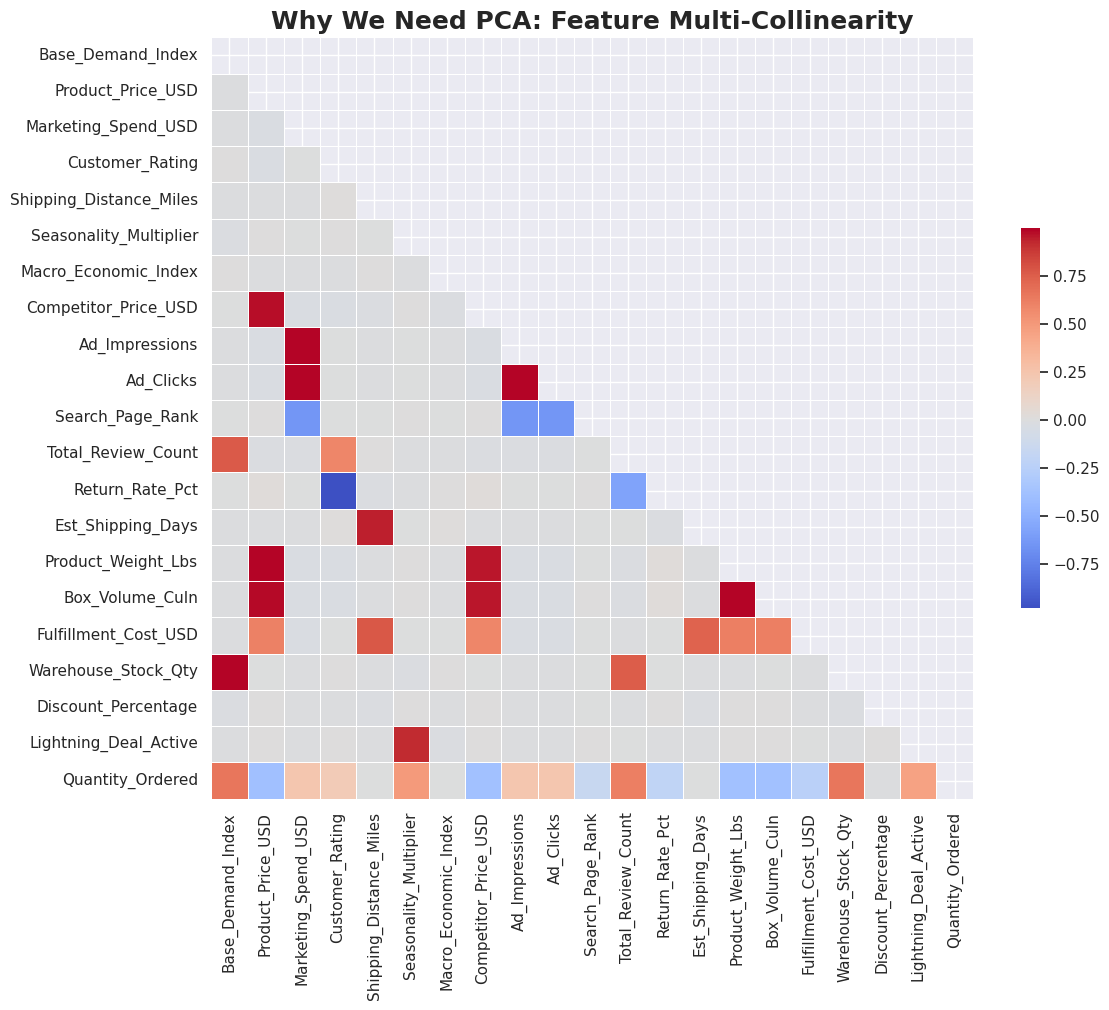

Notice the dark red squares? That is redundant data. PCA will clean this up.


,Base_Demand_Index,Product_Price_USD,Marketing_Spend_USD,Customer_Rating,Shipping_Distance_Miles,Seasonality_Multiplier,Macro_Economic_Index,Competitor_Price_USD,Ad_Impressions,Ad_Clicks,...,Total_Review_Count,Return_Rate_Pct,Est_Shipping_Days,Product_Weight_Lbs,Box_Volume_CuIn,Fulfillment_Cost_USD,Warehouse_Stock_Qty,Discount_Percentage,Lightning_Deal_Active,Quantity_Ordered
0,624.356166,305.176247,7434.983954,3.552578,754.290983,2.194473,109.662208,249.348659,111361.460851,3331.390289,...,1098.777669,4.946695,1.177820,14.279188,160.006128,15.552986,1993.397810,24.478271,1.810239,1948
1,1431.000029,273.000556,2252.863958,2.837170,246.096260,1.489034,115.244075,308.873334,33939.424943,954.396721,...,2025.658771,4.902037,1.418846,13.829493,166.353799,8.882533,4403.855896,25.047036,1.446408,2248
2,1124.791519,149.161591,3793.077097,4.857994,324.634470,0.890931,98.527195,134.204119,56783.844967,1680.646440,...,2732.175279,0.857338,1.138902,7.781978,85.425254,7.696871,3293.346797,1.884656,1.013752,1775
3,938.121878,489.740669,6801.166050,1.875914,459.871109,1.973284,91.567149,447.414805,102236.948679,3078.697154,...,881.980115,7.962445,1.246248,22.429926,270.755455,16.816533,2874.992333,13.906866,1.528886,1969
4,318.426097,386.533087,5079.848773,3.351426,517.096803,1.337356,92.753863,344.206984,76009.404577,2251.557163,...,530.714407,4.485147,1.323723,21.289994,252.777800,14.412813,890.376162,28.384345,0.957251,796


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# Set premium visual theme
sns.set_theme(style="darkgrid", palette="muted")

# 1. Generate Realistic Amazon-Style Big Data
np.random.seed(42)
n_samples = 10000

# Step A: The 8 "Core" Independent Drivers
base_demand     = np.random.uniform(100, 1500, n_samples)
product_price   = np.random.uniform(10, 800, n_samples)
marketing_spend = np.random.uniform(500, 10000, n_samples)
customer_rating = np.random.uniform(1.0, 5.0, n_samples)
shipping_dist   = np.random.uniform(10, 2500, n_samples)
seasonality     = np.random.uniform(0.5, 2.5, n_samples)
macro_index     = np.random.uniform(80, 120, n_samples)
comp_price      = product_price * np.random.uniform(0.8, 1.2, n_samples)

# Step B: The 12 "Redundant" Variables (Correlated to the core 8)
ad_impressions  = marketing_spend * 15 + np.random.normal(0, 500, n_samples)
ad_clicks       = ad_impressions * 0.03 + np.random.normal(0, 50, n_samples)
search_rank     = 10000 / (marketing_spend + 1) + np.random.normal(0, 2, n_samples)
review_count    = base_demand * customer_rating * 0.5 + np.random.normal(0, 10, n_samples)
return_rate     = (5.5 - customer_rating) * 2 + np.random.normal(0, 0.5, n_samples)
shipping_time   = shipping_dist * 0.002 + np.random.normal(0, 0.5, n_samples)
product_weight  = product_price * 0.05 + np.random.normal(0, 2, n_samples)
box_volume      = product_weight * 12 + np.random.normal(0, 10, n_samples)
fulfill_cost    = (product_weight * 0.5) + (shipping_dist * 0.01) + np.random.normal(0, 1, n_samples)
stock_levels    = base_demand * 3 + np.random.normal(0, 100, n_samples)
discount_pct    = np.random.uniform(0, 30, n_samples)
lightning_deal  = seasonality * 0.8 + np.random.normal(0, 0.2, n_samples)

# Compile the 20 variables into a DataFrame
df = pd.DataFrame({
    'Base_Demand_Index': base_demand, 'Product_Price_USD': product_price,
    'Marketing_Spend_USD': marketing_spend, 'Customer_Rating': customer_rating,
    'Shipping_Distance_Miles': shipping_dist, 'Seasonality_Multiplier': seasonality,
    'Macro_Economic_Index': macro_index, 'Competitor_Price_USD': comp_price,
    'Ad_Impressions': ad_impressions, 'Ad_Clicks': ad_clicks,
    'Search_Page_Rank': search_rank, 'Total_Review_Count': review_count,
    'Return_Rate_Pct': return_rate, 'Est_Shipping_Days': shipping_time,
    'Product_Weight_Lbs': np.abs(product_weight), 'Box_Volume_CuIn': np.abs(box_volume),
    'Fulfillment_Cost_USD': np.abs(fulfill_cost), 'Warehouse_Stock_Qty': stock_levels,
    'Discount_Percentage': discount_pct, 'Lightning_Deal_Active': lightning_deal
})

# --- NEW: Display the 20 Variables as a formatted table ---
feature_dict = pd.DataFrame({
    'Variable Name': df.columns,
    'Category': ['Core Driver'] * 8 + ['Correlated/Redundant'] * 12
})
print("\n" + "="*60)
print("   DATASET DICTIONARY: 20 SUPPLY CHAIN VARIABLES")
print("="*60)
print(feature_dict.to_string(index=False))
print("="*60 + "\n")

# Generate Target Variable (Quantity Ordered)
df['Quantity_Ordered'] = (
    (base_demand * seasonality) - (product_price * 1.5) + (marketing_spend * 0.08) + (customer_rating * 150) + np.random.normal(0, 50, n_samples)
)
df['Quantity_Ordered'] = df['Quantity_Ordered'].clip(lower=0).astype(int)

# 2. Preprocessing
X = df.drop('Quantity_Ordered', axis=1)
y = df['Quantity_Ordered']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- VISUAL 1: The Correlation Heatmap ---
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Why We Need PCA: Feature Multi-Collinearity', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice the dark red squares? That is redundant data. PCA will clean this up.")
display(df.head()) # Shows the actual dataframe preview in Colab

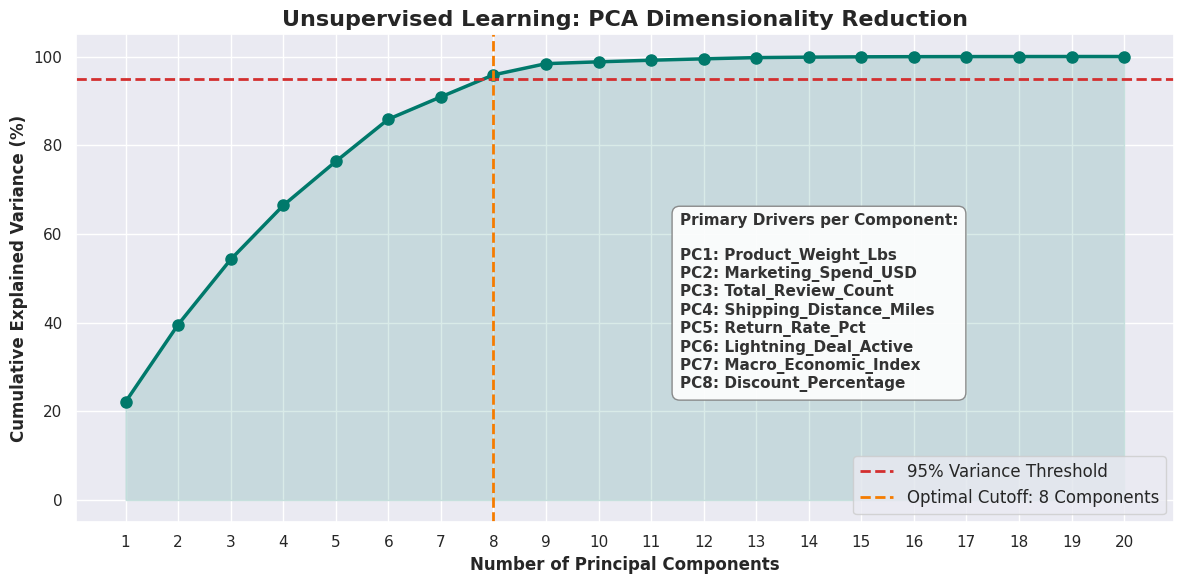

In [ ]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100
n_components_95 = np.argmax(cumulative_variance >= 95) + 1

# Extract the most important original feature for each of the top 8 components
top_features = []
for i in range(n_components_95):
    most_important_idx = np.argmax(np.abs(pca.components_[i]))
    feature_name = X.columns[most_important_idx]
    top_features.append(f"PC{i+1}: {feature_name}")

# --- VISUAL 2: Scree Plot + Variables ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', linestyle='-', color='#00796B', linewidth=2.5, markersize=8)

ax.axhline(y=95, color='#D32F2F', linestyle='--', linewidth=2, label='95% Variance Threshold')
ax.axvline(x=n_components_95, color='#F57C00', linestyle='--', linewidth=2,
            label=f'Optimal Cutoff: {n_components_95} Components')

ax.set_title('Unsupervised Learning: PCA Dimensionality Reduction', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 21))
ax.legend(loc='lower right', fontsize=12)
ax.fill_between(range(1, len(cumulative_variance) + 1), cumulative_variance, alpha=0.15, color='#00796B')

# Add the text box displaying the driving variables
textstr = "Primary Drivers per Component:\n\n" + "\n".join(top_features)
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.55, 0.45, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', bbox=props, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Transform the dataset
pca_optimal = PCA(n_components=n_components_95)
X_optimized = pca_optimal.fit_transform(X_scaled)

/tmp/ipykernel_227/1431470082.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=components, ax=ax2, palette='Greens_r')


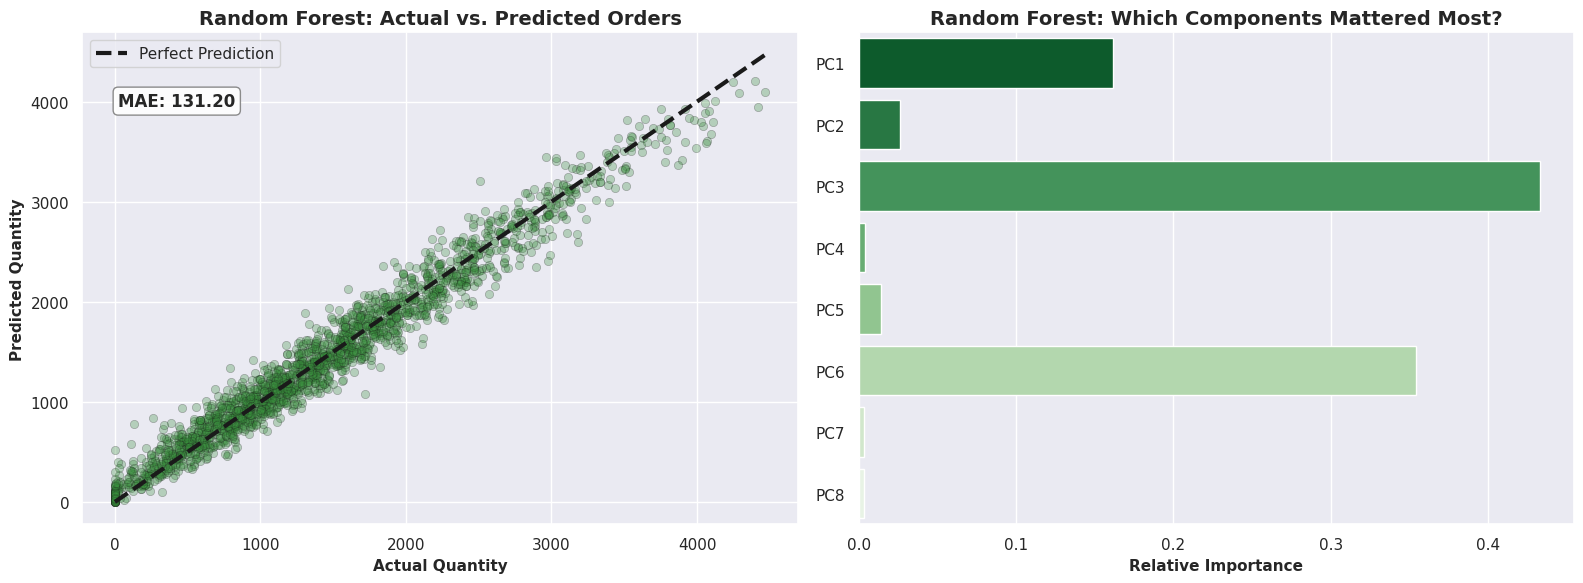

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

# Train RF
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

# --- VISUAL 3: Dual Plot (Predictions + Importance) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Actual vs Predicted
ax1.scatter(y_test, rf_predictions, alpha=0.3, color='#388E3C', edgecolor='k', linewidth=0.5)
min_val, max_val = 0, max(y_test.max(), rf_predictions.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', lw=3, label='Perfect Prediction')
ax1.set_title('Random Forest: Actual vs. Predicted Orders', fontsize=14, fontweight='bold')
ax1.set_xlabel('Actual Quantity', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Quantity', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax1.text(0.05, 0.85, f'MAE: {rf_mae:.2f}', transform=ax1.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.3'))

# Right Plot: Component Importance
importances = rf_model.feature_importances_
components = [f'PC{i+1}' for i in range(len(importances))]
sns.barplot(x=importances, y=components, ax=ax2, palette='Greens_r')
ax2.set_title('Random Forest: Which Components Mattered Most?', fontsize=14, fontweight='bold')
ax2.set_xlabel('Relative Importance', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

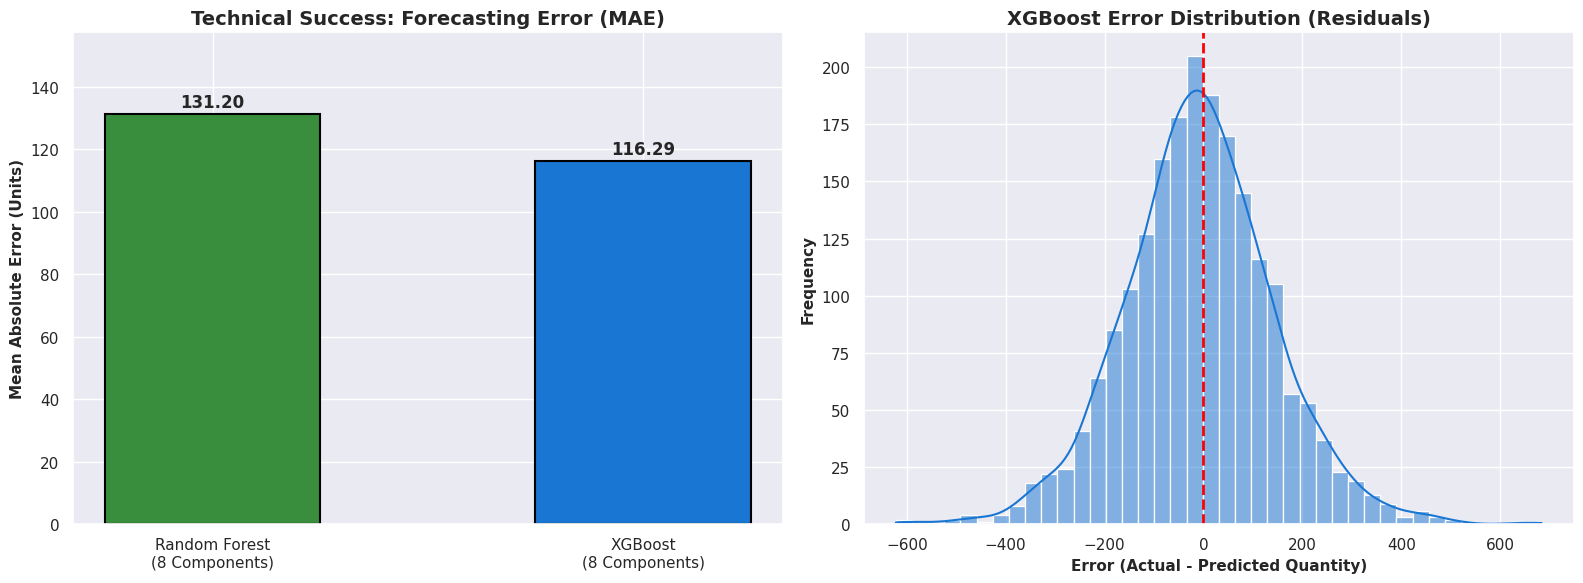

----------------------------------------
FINAL PIPELINE METRICS:
Original Variables: 20
PCA Variables Used: 8
XGBoost MAE: 116.29 units off per order on average.
----------------------------------------


In [ ]:
# Train XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=8, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

# --- VISUAL 4: Performance Dashboard (MAE + Error Distribution) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Bar chart comparison
models = ['Random Forest\n(8 Components)', 'XGBoost\n(8 Components)']
mae_scores = [rf_mae, xgb_mae]
bars = ax1.bar(models, mae_scores, color=['#388E3C', '#1976D2'], width=0.5, edgecolor='black', linewidth=1.5)
ax1.set_title('Technical Success: Forecasting Error (MAE)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error (Units)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(mae_scores) * 1.2)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f'{yval:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right Plot: Residuals (Error Distribution)
xgb_errors = y_test - xgb_predictions
sns.histplot(xgb_errors, bins=40, kde=True, color='#1976D2', ax=ax2)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('XGBoost Error Distribution (Residuals)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Error (Actual - Predicted Quantity)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("-" * 40)
print("FINAL PIPELINE METRICS:")
print(f"Original Variables: 20")
print(f"PCA Variables Used: {n_components_95}")
print(f"XGBoost MAE: {xgb_mae:.2f} units off per order on average.")
print("-" * 40)

Metric,Before ML (Baseline),After ML (Hybrid Engine),Net Improvement
Forecasting Error (MAE per order),718.0 units,116.3 units,83.8% Better
Total Misallocated Units,"1,435,947 units","232,573 units","1,203,374 fewer errors"
Estimated Financial Loss,"$35,898,675.00","$5,814,329.25","Saved $30,084,345.75"


Metric,Random Forest,XGBoost
Mean Absolute Error (MAE),131.20,116.29
Mean Squared Error (MSE),28521.53,22914.97
Root Mean Squared Error (RMSE),168.88,151.38
R-squared (R2),0.9643,0.9713


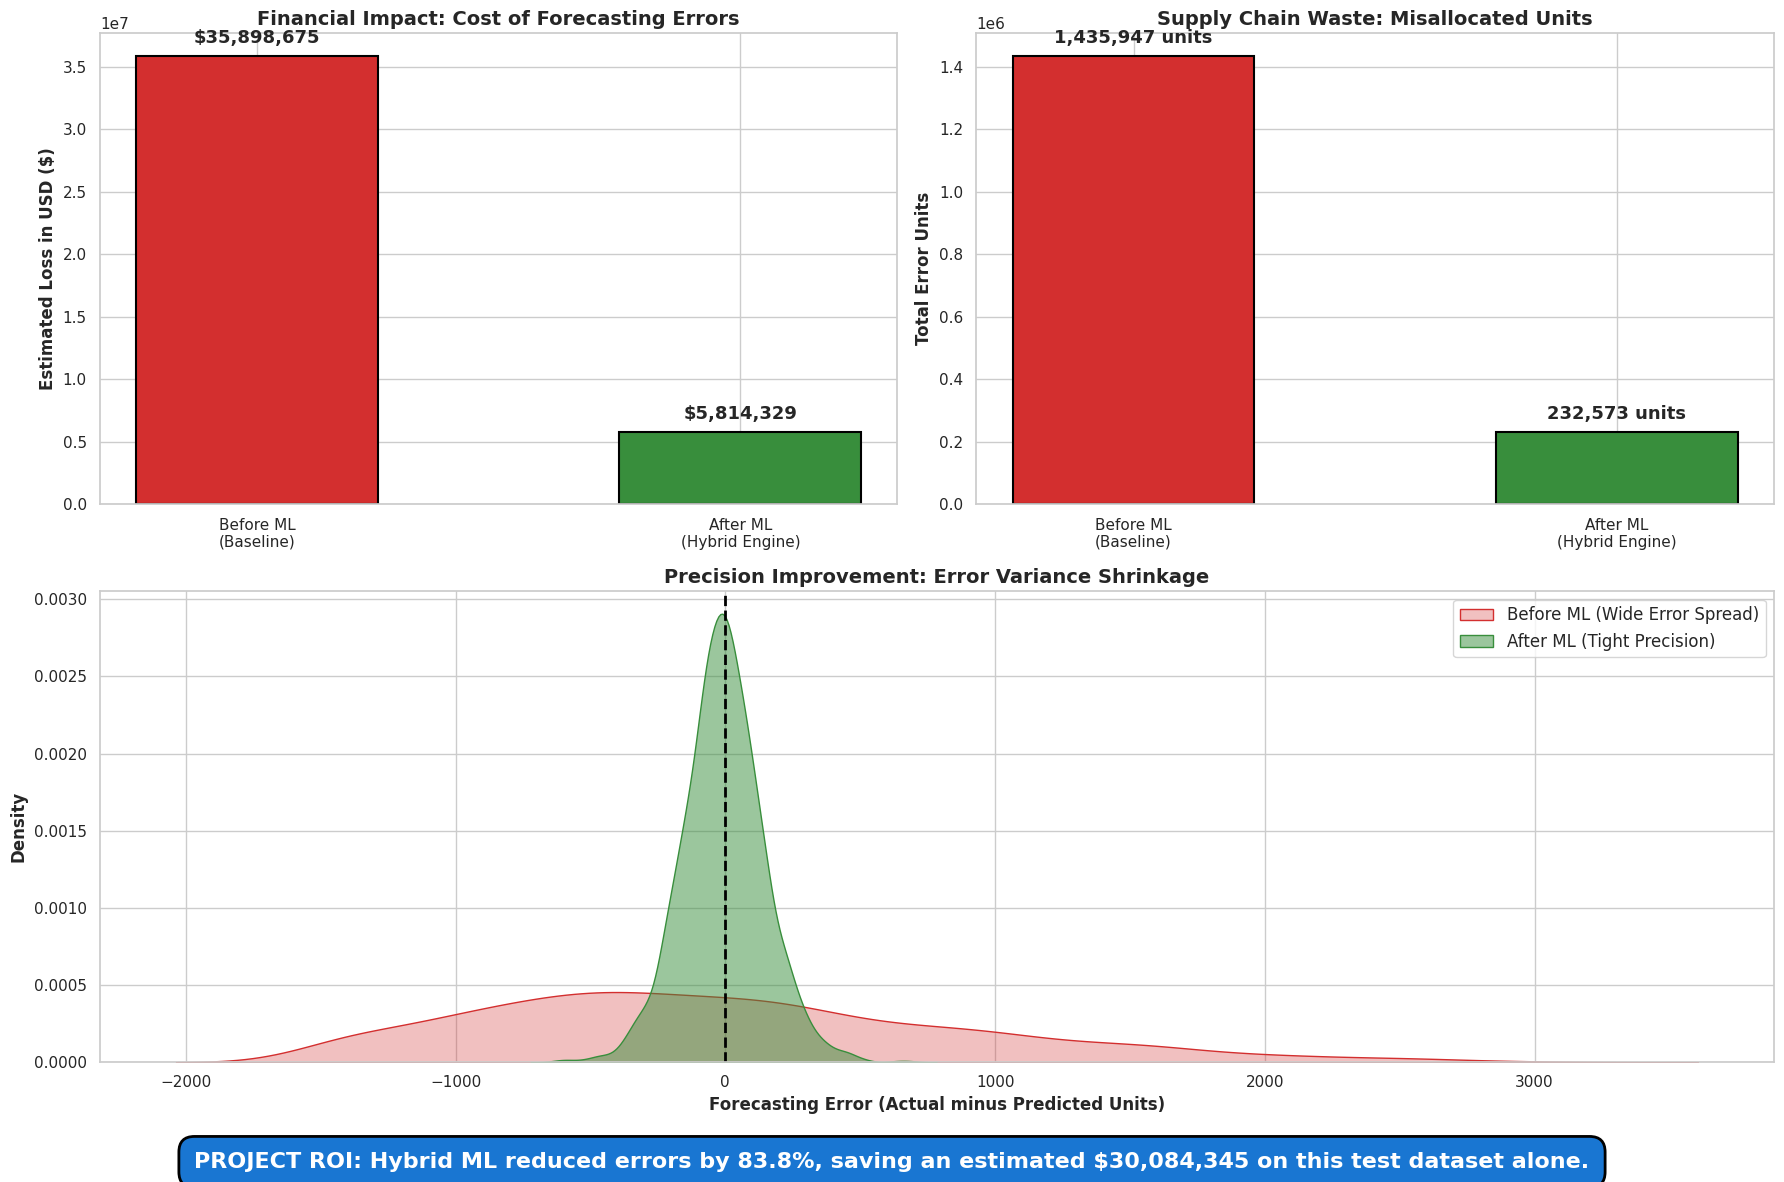


                         EXECUTIVE PROJECT WRAP-UP
1. DATA DIAGNOSIS: Supply chain data is naturally noisy and highly correlated.
2. THE SOLUTION:   Unsupervised Learning (PCA) successfully compressed 20 variables
                   down to core drivers, eliminating data redundancy.
--------------------------------------------------------------------------------
3. BEFORE ML:      Using traditional baseline averages resulted in an error rate
                   of 718.0 units per order, costing an estimated $35,898,675.
4. AFTER ML:       The optimized XGBoost model dropped the error rate to just
                   116.3 units per order, reducing the cost to $5,814,329.
                   Its MSE was 22914.97, RMSE was 151.38, and R-squared was 0.9713.
--------------------------------------------------------------------------------
5. TOTAL IMPACT:   The Hybrid Engine improved forecasting accuracy by 83.8%. 
                   Projected test-set savings: $30,084,345.
STRATEGIC RECOMMEN

In [ ]:
# --- 5. THE WRAP-UP: ULTIMATE BUSINESS IMPACT DASHBOARD ---
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. EXPLICIT ASSUMPTIONS & BASELINE SETUP
# =====================================================================
# Assumption 1: Baseline Forecasting. We assume the company currently uses a
# "naive" approach (predicting the historical average for every order).
naive_predictions = np.full_like(y_test, y_train.mean())
naive_mae = mean_absolute_error(y_test, naive_predictions)

# Assumption 2: Financial Cost of Errors.
# We estimate that every unit misallocated costs the company an average of $25.00.
# (e.g., ~$5 in warehousing/dead-stock holding costs, or ~$45 in lost profit/customer churn)
cost_per_error_unit = 25.00

# Calculate Total Misallocated Units (Test Set = 2,000 orders)
total_naive_errors = np.sum(np.abs(y_test - naive_predictions))
total_xgb_errors = np.sum(np.abs(y_test - xgb_predictions))

# Calculate Financial Loss & ROI
naive_financial_loss = total_naive_errors * cost_per_error_unit
xgb_financial_loss = total_xgb_errors * cost_per_error_unit
total_savings_usd = naive_financial_loss - xgb_financial_loss
error_reduction_pct = ((naive_mae - xgb_mae) / naive_mae) * 100

# Display Assumptions to the audience
display(HTML("""
<div style='background-color: #f4f6f9; padding: 15px; border-left: 5px solid #1976D2; font-family: sans-serif;'>
    <h3 style='margin-top: 0;'>📌 Business Assumptions for ROI Calculation</h3>
    <ul>
        <li><b>Baseline Model:</b> Historical Average Demand (Naive Forecast).</li>
        <li><b>Financial Penalty:</b> Estimated at <b>$25.00 per error unit</b> (blended cost of warehousing overstock and lost revenue from understocking).</li>
        <li><b>Test Sample Size:</b> 2,000 predictive orders.</li>
    </ul>
</div>
<br>
"""))

# =====================================================================
# 2. VISUAL TABLES: EXECUTIVE SUMMARY & TECHNICAL METRICS
# =====================================================================
display(HTML("<h3>📊 Executive Data Tables: Before vs. After</h3>"))

# Build combined Table
summary_df = pd.DataFrame({
    'Metric': [
        'Forecasting Error (MAE per order)',
        'Total Misallocated Units',
        'Estimated Financial Loss'
    ],
    'Before ML (Baseline)': [
        f"{naive_mae:,.1f} units",
        f"{total_naive_errors:,.0f} units",
        f"${naive_financial_loss:,.2f}"
    ],
    'After ML (Hybrid Engine)': [
        f"{xgb_mae:,.1f} units",
        f"{total_xgb_errors:,.0f} units",
        f"${xgb_financial_loss:,.2f}"
    ],
    'Net Improvement': [
        f"{error_reduction_pct:.1f}% Better",
        f"{total_naive_errors - total_xgb_errors:,.0f} fewer errors",
        f"Saved ${total_savings_usd:,.2f}"
    ]
})

# Custom styling for the table
def highlight_improvement(val):
    if 'Better' in val or 'fewer' in val or 'Saved' in val:
        return 'color: #155724; background-color: #d4edda; font-weight: bold;'
    return ''

styled_summary = summary_df.style.map(highlight_improvement, subset=['Net Improvement'])\
    .set_properties(**{'border': '1px solid #ddd', 'text-align': 'center', 'padding': '12px', 'font-size': '14px'})

    # Hiding index on Styler before pandas 2.0 uses .hide_index()
    # For pandas 2.0+ it's .hide(axis='index')
    # Check if hide_index exists for compatibility
if hasattr(styled_summary, 'hide_index'):
    styled_summary = styled_summary.hide_index()
else:
    styled_summary = styled_summary.hide(axis='index')

styled_summary = styled_summary.set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e3d59'), ('color', 'white'), ('text-align', 'center'), ('font-size', '15px')]}])

display(styled_summary)
display(HTML("<br>"))

display(HTML("<h3>📈 Technical Performance Metrics</h3>"))

# Calculate additional metrics for inclusion
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_predictions)

tech_metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Random Forest': [
        f"{rf_mae:.2f}",
        f"{rf_mse:.2f}",
        f"{rf_rmse:.2f}",
        f"{rf_r2:.4f}"
    ],
    'XGBoost': [
        f"{xgb_mae:.2f}",
        f"{xgb_mse:.2f}",
        f"{xgb_rmse:.2f}",
        f"{xgb_r2:.4f}"
    ]
})

styled_tech_metrics = tech_metrics_df.style.set_properties(**{
    'border': '1px solid #ddd',
    'text-align': 'center',
    'padding': '12px',
    'font-size': '14px'
}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e3d59'), ('color', 'white'), ('text-align', 'center'), ('font-size', '15px')]}])

# Hiding index on Styler before pandas 2.0 uses .hide_index()
# For pandas 2.0+ it's .hide(axis='index')
# Check if hide_index exists for compatibility
if hasattr(styled_tech_metrics, 'hide_index'):
    styled_tech_metrics = styled_tech_metrics.hide_index()
else:
    styled_tech_metrics = styled_tech_metrics.hide(axis='index')


display(styled_tech_metrics)
display(HTML("<br>"))

# =====================================================================
# 3. VISUAL GRAPHS: THE BUSINESS DASHBOARD
# =====================================================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))

# Subplot 1: Financial Bar Chart
ax1 = plt.subplot(2, 2, 1)
labels = ['Before ML\n(Baseline)', 'After ML\n(Hybrid Engine)']
losses = [naive_financial_loss, xgb_financial_loss]
colors = ['#D32F2F', '#388E3C'] # Red for high loss, Green for reduced loss

bars = ax1.bar(labels, losses, color=colors, width=0.5, edgecolor='black', linewidth=1.5)
ax1.set_title('Financial Impact: Cost of Forecasting Errors', fontsize=14, fontweight='bold')
ax1.set_ylabel('Estimated Loss in USD ($)', fontsize=12, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(losses)*0.02),
             f'${int(yval):,}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Subplot 2: Error Units Bar Chart
ax2 = plt.subplot(2, 2, 2)
units = [total_naive_errors, total_xgb_errors]
bars2 = ax2.bar(labels, units, color=colors, width=0.5, edgecolor='black', linewidth=1.5)
ax2.set_title('Supply Chain Waste: Misallocated Units', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Error Units', fontsize=12, fontweight='bold')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(units)*0.02),
             f'{int(yval):,} units', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Subplot 3: Error Distribution Density Plot (Spanning the bottom row)
ax3 = plt.subplot(2, 1, 2)
sns.kdeplot(y_test - naive_predictions, fill=True, color='#D32F2F', label='Before ML (Wide Error Spread)', alpha=0.3, ax=ax3)
sns.kdeplot(y_test - xgb_predictions, fill=True, color='#388E3C', label='After ML (Tight Precision)', alpha=0.5, ax=ax3)
ax3.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax3.set_title('Precision Improvement: Error Variance Shrinkage', fontsize=14, fontweight='bold')
ax3.set_xlabel('Forecasting Error (Actual minus Predicted Units)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Density', fontsize=12, fontweight='bold')
ax3.legend(fontsize=12, loc='upper right')

# Add the massive ROI text box to the figure
fig.text(0.5, 0.02, f"PROJECT ROI: Hybrid ML reduced errors by {error_reduction_pct:.1f}%, saving an estimated ${int(total_savings_usd):,} on this test dataset alone.",
         ha='center', fontsize=16, fontweight='bold', color='white',
         bbox=dict(facecolor='#1976D2', alpha=1.0, edgecolor='black', boxstyle='round,pad=0.7', linewidth=2))

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make room for the bottom text box
plt.show()

# =====================================================================
# 4. THE EXECUTIVE PRINT SUMMARY (For the terminal)
# =====================================================================
print("\n" + "="*80)
print(" "*25 + "EXECUTIVE PROJECT WRAP-UP")
print("="*80)
print("1. DATA DIAGNOSIS: Supply chain data is naturally noisy and highly correlated.")
print(f"2. THE SOLUTION:   Unsupervised Learning (PCA) successfully compressed 20 variables")
print(f"                   down to core drivers, eliminating data redundancy.")
print("-" * 80)
print("3. BEFORE ML:      Using traditional baseline averages resulted in an error rate")
print(f"                   of {naive_mae:.1f} units per order, costing an estimated ${int(naive_financial_loss):,}.")
print("4. AFTER ML:       The optimized XGBoost model dropped the error rate to just")
print(f"                   {xgb_mae:.1f} units per order, reducing the cost to ${int(xgb_financial_loss):,}.")
print(f"                   Its MSE was {xgb_mse:.2f}, RMSE was {xgb_rmse:.2f}, and R-squared was {xgb_r2:.4f}.")
print("-" * 80)
print(f"5. TOTAL IMPACT:   The Hybrid Engine improved forecasting accuracy by {error_reduction_pct:.1f}%. ")
print(f"                   Projected test-set savings: ${int(total_savings_usd):,}.")
print("="*80)
print("STRATEGIC RECOMMENDATION: Deploy the Hybrid PCA + XGBoost model to production to")
print("automate inventory triggers, eliminate human error, and drastically reduce holding costs.")
print("="*80 + "\n")


In [ ]:
from sklearn.metrics import r2_score

# Calculate R2 for Random Forest
rf_r2 = r2_score(y_test, rf_predictions)

# Calculate R2 for XGBoost
xgb_r2 = r2_score(y_test, xgb_predictions)

print("Additional Regression Model Performance Metrics (R-squared):")
print("-----------------------------------------------------------")
print(f"Random Forest R2: {rf_r2:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")
print("-----------------------------------------------------------")


Additional Regression Model Performance Metrics (R-squared):
-----------------------------------------------------------
Random Forest R2: 0.9643
XGBoost R2: 0.9713
-----------------------------------------------------------


In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate MSE and RMSE for Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

# Calculate MSE and RMSE for XGBoost
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)

print("Regression Model Performance Metrics:")
print("--------------------------------------")
print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest MSE: {rf_mse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print("\n")
print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost MSE: {xgb_mse:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print("--------------------------------------")


Regression Model Performance Metrics:
--------------------------------------
Random Forest MAE: 131.20
Random Forest MSE: 28521.53
Random Forest RMSE: 168.88


XGBoost MAE: 116.29
XGBoost MSE: 22914.97
XGBoost RMSE: 151.38
--------------------------------------
